In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# استدعاء البيانات وتحديد الستايل
df_clean = pd.read_csv('Telco_Customer_Churn_After_Cleaned.csv')
plt.style.use('seaborn-v0_8-whitegrid')

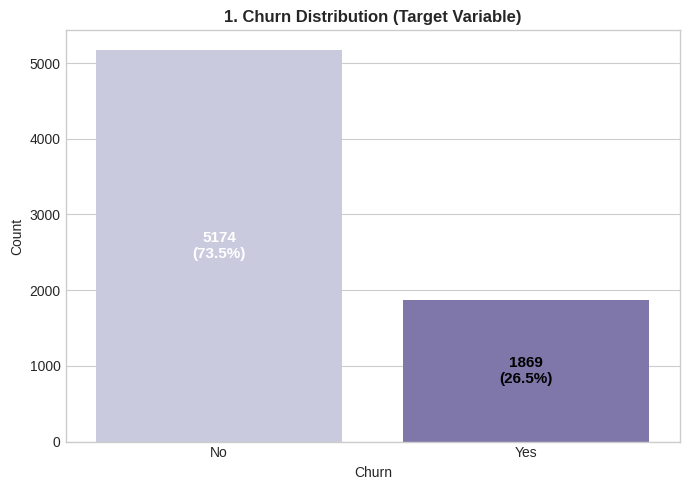

In [ ]:
# 1. Churn Distribution
plt.figure(figsize=(7, 5))
ax1 = sns.countplot(data=df_clean, x='Churn', hue='Churn', palette='Purples')
plt.title('1. Churn Distribution (Target Variable)', fontsize=12, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')

total = len(df_clean)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height/total)*100:.1f}%'
        ax1.annotate(f'{int(height)}\n({percentage})',
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha='center', va='center', fontsize=11,
                     color='white' if height > 3000 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

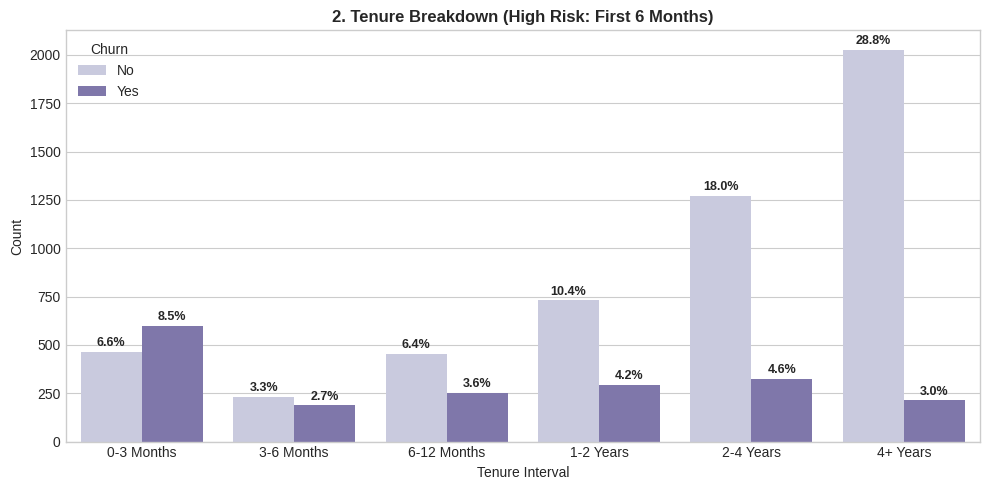

In [ ]:
# إعادة تقسيم tenure مع إبراز أول 6 أشهر كعنق زجاجة
def tenure_detailed(months):
    if months <= 3:
        return '0-3 Months'
    elif months <= 6:
        return '3-6 Months'
    elif months <= 12:
        return '6-12 Months'
    elif months <= 24:
        return '1-2 Years'
    elif months <= 48:
        return '2-4 Years'
    else:
        return '4+ Years'

df_clean['tenure_detailed'] = df_clean['tenure'].apply(tenure_detailed)
detailed_order = ['0-3 Months', '3-6 Months', '6-12 Months', '1-2 Years', '2-4 Years', '4+ Years']

# 2. Tenure Distribution - Critical Months Focus
plt.figure(figsize=(10, 5))
ax2 = sns.countplot(data=df_clean, x='tenure_detailed', hue='Churn', order=detailed_order, palette='Purples')
plt.title('2. Tenure Breakdown (High Risk: First 6 Months)', fontsize=12, fontweight='bold')
plt.xlabel('Tenure Interval')
plt.ylabel('Count')

total = len(df_clean)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height/total)*100:.1f}%'
        ax2.annotate(f'{percentage}', (p.get_x() + p.get_width() / 2., height + 15),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

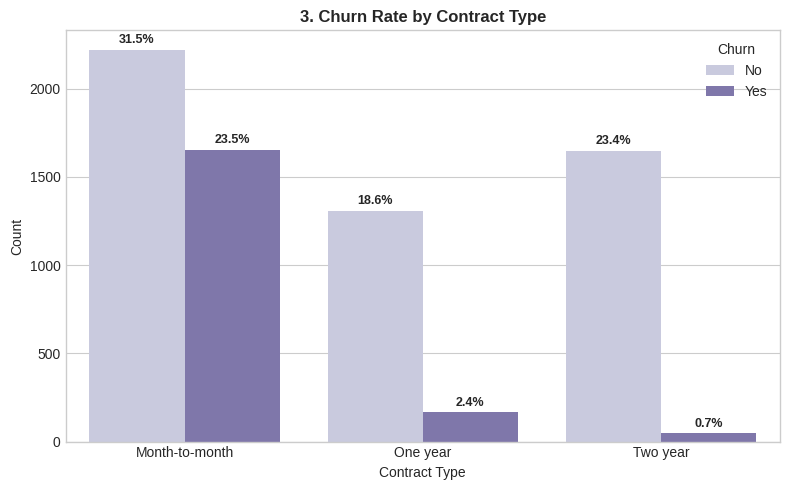

In [ ]:
# 3. Contract Type vs Churn
plt.figure(figsize=(8, 5))
ax3 = sns.countplot(data=df_clean, x='Contract', hue='Churn', palette='Purples')
plt.title('3. Churn Rate by Contract Type', fontsize=12, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Count')

for p in ax3.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height/total)*100:.1f}%'
        ax3.annotate(f'{percentage}', (p.get_x() + p.get_width() / 2., height + 20),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

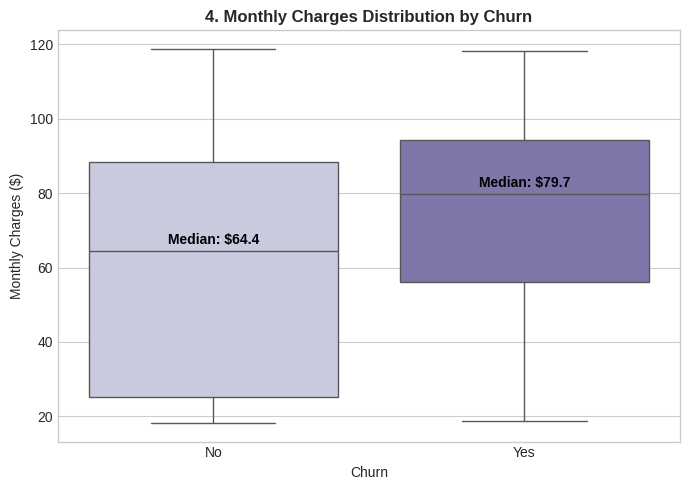

In [ ]:
# 4. Monthly Charges vs Churn
plt.figure(figsize=(7, 5))
ax4 = sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', hue='Churn', palette='Purples')
plt.title('4. Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')

medians = df_clean.groupby('Churn')['MonthlyCharges'].median()
for i, median in enumerate(medians):
    ax4.text(i, median + 2, f'Median: ${median:.1f}', horizontalalignment='center', size=10, color='black', weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# 2. تحديد المتغيرات الثنائية ومتعددة الفئات
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
multi_cols = [c for c in df_clean.select_dtypes(include=['object']).columns if c not in binary_cols]

In [ ]:
# 3. تطبيق Binary Encoding (تحويل Yes/No و Male/Female إلى 1 و 0)
df_encoded = df_clean.copy()
for col in binary_cols:
    if col in df_encoded.columns:
        # التعامل مع gender بشكل خاص أو تحويل أي Yes/No
        if set(df_encoded[col].unique()) == {'Yes', 'No'}:
            df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})
        elif set(df_encoded[col].unique()) == {'Female', 'Male'}:
            df_encoded[col] = df_encoded[col].map({'Male': 1, 'Female': 0})

In [ ]:
# 4. تطبيق One-Hot Encoding على المتغيرات الفئوية المتعددة
df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True, dtype=int)

In [ ]:
# 5. فصل الميزات (X) عن الهدف (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [ ]:
# 6. تقسيم البيانات (80% تدريب - 20% اختبار) مع الحفاظ على نسبة التوزيع (Stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
# 7. تطبيق المعاييرة StandardScaler على الأعمدة الرقمية فقط
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
# Fit & Transform على داتا التدريب
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# Transform فقط على داتا الاختبار (لمنع تسريب البيانات)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✅ تم تجهيز البيانات بنجاح!")
print(f"أبعاد داتا التدريب (X_train): {X_train.shape}")
print(f"أبعاد داتا الاختبار (X_test): {X_test.shape}")

✅ تم تجهيز البيانات بنجاح!
أبعاد داتا التدريب (X_train): (5634, 34)
أبعاد داتا الاختبار (X_test): (1409, 34)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# ---------------------------------------------------------
# 1. تدريب النموذج الأول: Logistic Regression
# ---------------------------------------------------------

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# التنبؤ بالفئات واللاحتمالات (نسبة مئوية)
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1] # نسبة احتمال Churn=1

# ---------------------------------------------------------
# 2. تدريب النموذج الثاني: Random Forest
# ---------------------------------------------------------

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# التنبؤ بالفئات واللاحتمالات
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# 3. عرض تقرير الأداء التفصيلي (Classification Report)
# ---------------------------------------------------------

In [ ]:
print("="*50)
print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_log))

print("="*50)
print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



# ---------------------------------------------------------
# 4. رسم Confusion Matrix الملونة للنموذجين
# ---------------------------------------------------------

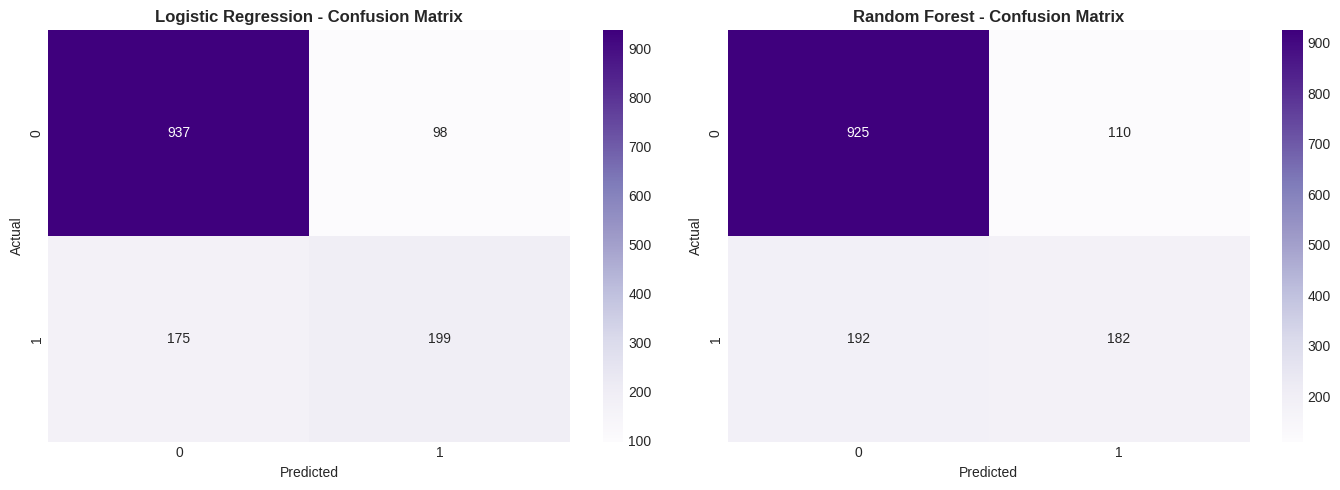

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. رسم منحنى ROC Curve للمقارنة بين الموديلين
# ---------------------------------------------------------

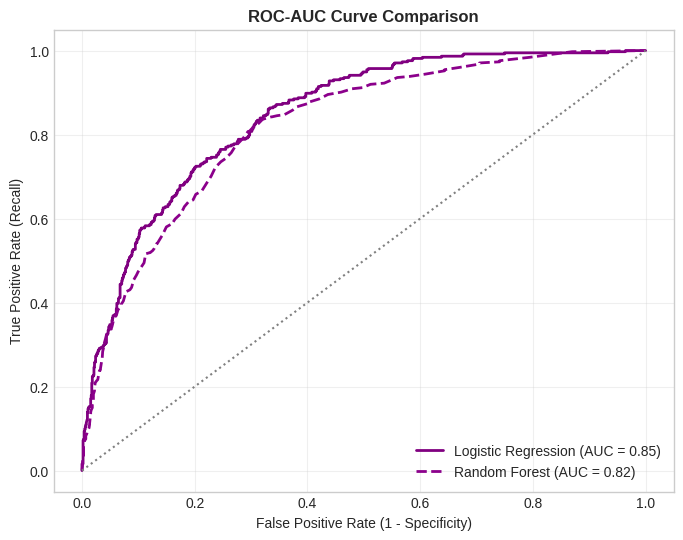

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='purple', linewidth=2, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, color='darkmagenta', linestyle='--', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')

plt.title('ROC-AUC Curve Comparison', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 6. رسم الميزات الأكثر تأثيراً (Feature Importance - Random Forest)
# ---------------------------------------------------------

/tmp/ipykernel_637/2271331798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Purples_r')


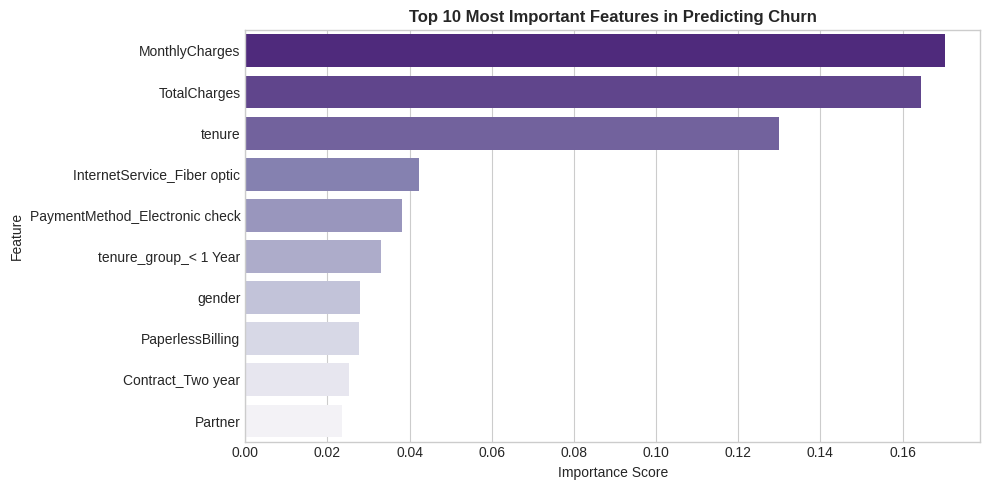

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Purples_r')
plt.title('Top 10 Most Important Features in Predicting Churn', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# اختيار نموذج Logistic Regression المعتمد
final_model = log_model

# طباعة نسبة احتمالية التسرب لأول 5 عملاء في داتا الاختبار للتجربة
sample_customers = X_test.iloc[:5]
churn_probabilities = final_model.predict_proba(sample_customers)[:, 1]

for i, proba in enumerate(churn_probabilities):
    print(f"العميل رقم {i+1}: نسبة احتمال مغادرته للشركة هي {proba*100:.1f}%")

العميل رقم 1: نسبة احتمال مغادرته للشركة هي 2.1%
العميل رقم 2: نسبة احتمال مغادرته للشركة هي 68.7%
العميل رقم 3: نسبة احتمال مغادرته للشركة هي 7.5%
العميل رقم 4: نسبة احتمال مغادرته للشركة هي 33.3%
العميل رقم 5: نسبة احتمال مغادرته للشركة هي 1.3%


In [ ]:
def predict_and_recommend(customer_data):
    """
    دالة لحساب نسبة احتمالية التسرب واستخراج توصيات مخصصة بناءً على نقاط ضعف العميل.
    """
    # 1. تجهيز بيانات العميل بنفس خطوات التشفير والمعايرة
    input_df = pd.DataFrame([customer_data])

    for col in binary_cols:
        if col in input_df.columns:
            if input_df[col].iloc[0] in ['Yes', 'No']:
                input_df[col] = input_df[col].map({'Yes': 1, 'No': 0})
            elif input_df[col].iloc[0] in ['Male', 'Female']:
                input_df[col] = input_df[col].map({'Male': 1, 'Female': 0})

    input_encoded = pd.get_dummies(input_df, dtype=int)
    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)
    input_encoded[num_cols] = scaler.transform(input_encoded[num_cols])

    # 2. حساب الاحتمالية بالموديل المعتمد
    churn_proba = final_model.predict_proba(input_encoded)[0, 1]

    # 3. تحديد مستوى الخطورة
    if churn_proba >= 0.60:
        risk_level = "عالي الخطورة (High Risk) 🔴"
    elif churn_proba >= 0.30:
        risk_level = "متوسط الخطورة (Medium Risk) 🟠"
    else:
        risk_level = "منخفض الخطورة (Low Risk) 🟢"

    print("="*60)
    print(f"📊 نسبة احتمال مغادرة العميل للشركة: {churn_proba * 100:.2f}%")
    print(f"⚠️ تصنيف حالة العميل: {risk_level}")
    print("-" * 60)
    print("💡 التوصيات الإجراءية المخصصة (Actionable Recommendations):")

    # 4. محرك قواعد التوصيات المخصصة بناءً على مدخلات العميل
    recommendations = []

    if churn_proba >= 0.30: # إذا كان العميل معرضاً للخطر
        if customer_data.get('Contract') == 'Month-to-month':
            recommendations.append(" [العقد]: العقد شهري. يُنصح بتقديم خصم 15% للتحويل لعقد سنوي.")
        if customer_data.get('TechSupport') == 'No':
            recommendations.append(" [الدعم الفني]: افتقار العميل للدعم الفني. يُنصح بمنحه 3 أشهر دعم فني مجاناً.")
        if customer_data.get('OnlineSecurity') == 'No':
            recommendations.append(" [الأمان]: عدم تفعيل الحماية. يُنصح بإضافة حزمة Online Security لتثبيت العميل.")
        if customer_data.get('PaymentMethod') == 'Electronic check':
            recommendations.append(" [طريقة الدفع]: الدفع بشيك إلكتروني مرتفع الخطورة. يُفضل تحفيزه للدفع الآلي.")
        if customer_data.get('tenure', 0) <= 6:
            recommendations.append(" [فترة الاشتراك]: العميل جديد (أقل من 6 أشهر). يجب إدخاله في برنامج متابعة مكثف.")
    else:
        recommendations.append(" العميل مستقر! يمكن ترشيح باقات أعلى (Upselling) أو تقديم مكافآت ولاء.")

    for rec in recommendations:
        print(rec)
    print("="*60)

    return churn_proba

In [ ]:
# 🔴 حالة 1: عميل جديد بخصائص عالية الخطورة (عقد شهري، اشتراك عالي، مفيش حماية أو دعم فني)
high_risk_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,                          # بقاله شهرين بس
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',    # إنترنت فايبر برقم عالي
    'OnlineSecurity': 'No',              # مفيش حماية
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',                 # مفيش دعم فني
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',        # عقد شهري (عامل خطر كبير)
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', # دفع إلكتروني
    'MonthlyCharges': 95.5,
    'TotalCharges': 191.0
}

print("--- تجربة العميل الأول (خصائص عالية الخطورة) ---")
predict_new_customer_churn(high_risk_customer)

# 🟢 حالة 2: عميل بخصائص منخفضة الخطورة (عقد سنتين، tenure طويل، مشترك في الدعم والأمان)
low_risk_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'tenure': 48,                         # بقاله 4 سنين
    'PhoneService': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',             # مشترك في الأمان
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',                # مشترك في الدعم الفني
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Two year',              # عقد سنتين (أمان عالي)
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Credit card (automatic)',
    'MonthlyCharges': 55.0,
    'TotalCharges': 2640.0
}

print("\n--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---")
predict_new_customer_churn(low_risk_customer)

--- تجربة العميل الأول (خصائص عالية الخطورة) ---
📊 نسبة احتمال مغادرة العميل للشركة: 85.24%
⚠️ تصنيف حالة العميل: عالي الخطورة (High Risk) 🔴

--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---
📊 نسبة احتمال مغادرة العميل للشركة: 1.92%
⚠️ تصنيف حالة العميل: منخفض الخطورة (Low Risk) 🟢


np.float64(0.019193647811867005)

In [ ]:
# تجربة الدالة الجديدة على العميل الأول
predict_and_recommend(high_risk_customer)

📊 نسبة احتمال مغادرة العميل للشركة: 85.24%
⚠️ تصنيف حالة العميل: عالي الخطورة (High Risk) 🔴
------------------------------------------------------------
💡 التوصيات الإجراءية المخصصة (Actionable Recommendations):
 [العقد]: العقد شهري. يُنصح بتقديم خصم 15% للتحويل لعقد سنوي.
 [الدعم الفني]: افتقار العميل للدعم الفني. يُنصح بمنحه 3 أشهر دعم فني مجاناً.
 [الأمان]: عدم تفعيل الحماية. يُنصح بإضافة حزمة Online Security لتثبيت العميل.
 [طريقة الدفع]: الدفع بشيك إلكتروني مرتفع الخطورة. يُفضل تحفيزه للدفع الآلي.
 [فترة الاشتراك]: العميل جديد (أقل من 6 أشهر). يجب إدخاله في برنامج متابعة مكثف.


np.float64(0.8524250377264104)

In [ ]:
# تجربة الدالة الجديدة للعميل الثاني
print("\n--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---")
predict_and_recommend(low_risk_customer)


--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---
📊 نسبة احتمال مغادرة العميل للشركة: 1.92%
⚠️ تصنيف حالة العميل: منخفض الخطورة (Low Risk) 🟢
------------------------------------------------------------
💡 التوصيات الإجراءية المخصصة (Actionable Recommendations):
 العميل مستقر! يمكن ترشيح باقات أعلى (Upselling) أو تقديم مكافآت ولاء.


np.float64(0.019193647811867005)

In [44]:
import joblib

# 1. حفظ الموديل المعتمد (Logistic Regression)
joblib.dump(final_model, 'logistic_regression_model.pkl')

# 2. حفظ الـ Scaler لتنظيف وتحجيم أرقام البيانات الجديدة بنفس النمط
joblib.dump(scaler, 'scaler.pkl')

# 3. حفظ قائمة الأعمدة النهائية للتأكد من تطابق المدخلات في الفرونت إند
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("✅ تم حفظ الموديل والـ Scaler والأعمدة بنجاح جاهزة للاستخدام في الفرونت إند!")

✅ تم حفظ الموديل والـ Scaler والأعمدة بنجاح جاهزة للاستخدام في الفرونت إند!
